## Lab Practice Ensemble learning 1.3:  RANDOM FORESTS (CLASSWORK)  | Machine Learning II
#### ESU  Jan-2025
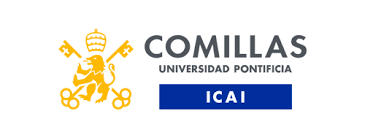

LEARNING OBJECTIVES
- How to run random forest with classification trees
- Deep understanding of the variability created by boostrap in the ensemble of trees

---
## Import modules

In [1]:
import numpy as np # linear algebra
import pandas as pd  # data management (dataframes)
import matplotlib.pyplot as plt
import seaborn as sns  # plotting

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from sklearn.inspection import permutation_importance

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
#from sklearn.ensemble import BaggingRegressor

# solve problems with size and fonts in figures 
plt.rcParams['figure.dpi'] = 75

# auxiliary functions
import utils_ml1 as uml1
import utils_classification_ml2 as ucml2

---
## 1. Classification problem

#### 1.1 Load the dataset

In [2]:
# Load file with the dataset
df = pd.read_csv('simDataTriangle.dat', sep = "\t")
print('Dataframe:')
print(df.head())

# Convert output variable to categorical
df.Y = df.Y.astype('category')

Dataframe:
         X1        X2        X3        X4        X5        X6    Y
0 -0.416315  5.704369 -0.520502  5.624744 -0.567509  5.657103  OUT
1 -0.052473  9.467372 -0.308278  9.518659 -0.028233  9.271118  OUT
2 -0.552123  7.329100 -0.563368  7.373105 -0.851291  7.175183  OUT
3  0.290578  7.804284  0.248642  7.461996 -0.038654  7.557059  INS
4  0.116236  7.472282  0.154657  7.231131  0.154816  7.462239  INS


#### 1.2 Exploratory analysis


Info variables:
               X1          X2          X3          X4          X5          X6
count  700.000000  700.000000  700.000000  700.000000  700.000000  700.000000
mean     0.484328    6.115594    0.488827    6.124073    0.487352    6.121143
std      0.606122    2.678621    0.633653    2.686707    0.632867    2.687277
min     -0.597901    0.010610   -0.906872   -0.182318   -0.973871   -0.090703
25%     -0.045126    4.507014   -0.009401    4.432009   -0.004716    4.415462
50%      0.475767    6.614707    0.508919    6.619594    0.479645    6.572260
75%      1.023133    8.265262    0.998416    8.306398    0.990994    8.278550
max      1.499564    9.976869    1.982567   10.558648    1.924748   10.294785


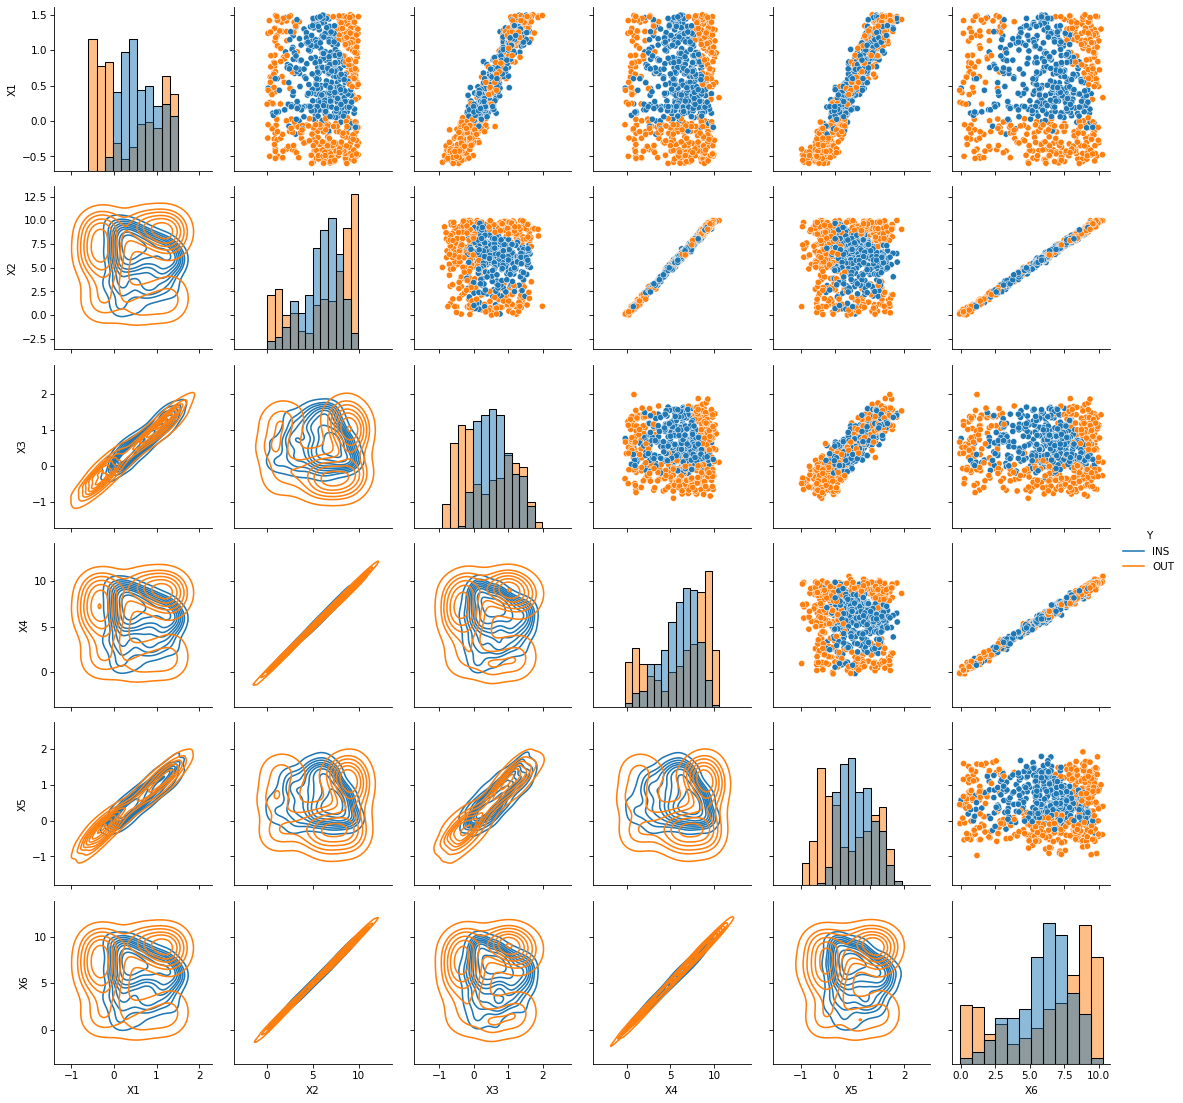

In [3]:
# Basic exploratory analysis

print('\nInfo variables:')
print(df.describe())

g = sns.PairGrid(df, hue="Y")
g.map_diag(sns.histplot)
#g.map_offdiag(sns.scatterplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.add_legend()

#### 1.3 Split the dataset in TR and TS

In [4]:
# Define input and output matrices
INPUTS = ['X1','X2','X3','X4','X5','X6']
OUTPUT = 'Y'
X = df[INPUTS]
y = df[OUTPUT]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0, #seed for replication
                                                    stratify = y)   #Preserves distribution of y

#### 1.4 Fit Bagged tree (For comparison with Random Forest)

In [5]:
# Para comparar con Random Forest, ajustamos  bagging con 50 árboles.

# Sin grid search
number_estimators = 50
base_estimator =  Pipeline(steps=[('DT', 
                                    DecisionTreeClassifier( criterion='gini',  # impurity measure
                                                            min_samples_split=2, # Minimum number of obs in node to keep cutting
                                                            min_samples_leaf=1, # Minimum number of obs in a terminal node
                                                            random_state=999))]) # For replication


bag_class_estim = BaggingClassifier(estimator=base_estimator,
                                    n_estimators=number_estimators,
                                    random_state=0)
                     
# fit the bagged trees. Le metemos todas las variables de entrada.
INPUTS_BT = INPUTS                 
bag_class_estim.fit(X_train[INPUTS_BT], y_train)

BaggingClassifier(estimator=Pipeline(steps=[('DT',
                                             DecisionTreeClassifier(random_state=999))]),
                  n_estimators=50, random_state=0)

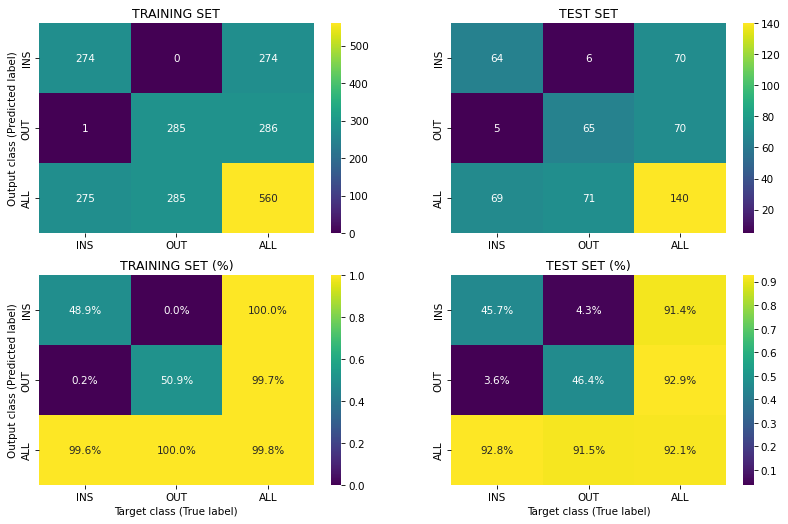

In [6]:
ucml2.plot_expanded_confusion_matrix(bag_class_estim, X_train, y_train, X_test, y_test)

# number of nodes in each tree of the ensemble
node_count_trees_bt = [t['DT'].tree_.node_count for t in bag_class_estim.estimators_]

# number of nodes in each tree of the ensemble
depth_trees_bt = [t['DT'].tree_.max_depth for t in bag_class_estim.estimators_]

### 1.5 Fit Random Forest (fixed hyperparam)

In [7]:
## M: número máximo de variables en cada nodo para elegir
### 1.6 Fit Random Forest
number_estimators = 50

# The number of features to consider when looking for the best split:
m = 'sqrt' # max_features{“sqrt”, “log2”, None}, int or float, default=”sqrt”

RF_class_estim = RandomForestClassifier(n_estimators=number_estimators,
                                        max_features=m, ## Variables que le dejamos explorar en cada nodo.
                                        criterion='gini',  # impurity measure
                                        min_samples_split=2, # Minimum number of obs in node to keep cutting
                                        min_samples_leaf=1, # Minimum number of obs in a terminal node  
                                        random_state=999)
                     
# fit the bagged trees
INPUTS_RT = INPUTS                 
RF_class_estim.fit(X_train[INPUTS_RT], y_train)

RandomForestClassifier(n_estimators=50, random_state=999)

El objetivo de del random forest es reducir la correlación entre ellas porque eso reduce el error al reducir la varianza a traves de reducir la convarianza (es importante entender la varianza de la suma de variables). Es cierto que empeora el sesgo, pero compensa ya que disminuye 
mucho el error.

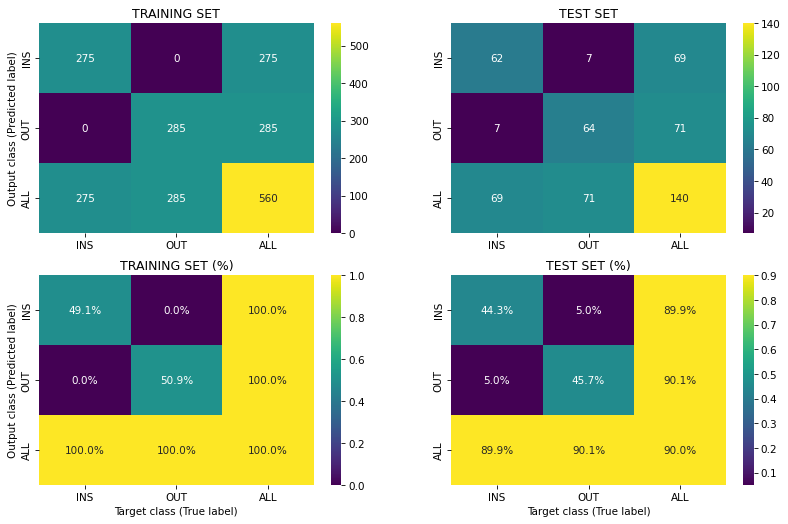

In [8]:
ucml2.plot_expanded_confusion_matrix(RF_class_estim, X_train, y_train, X_test, y_test)

#### 1.5.1 Plot some trees of the forest (top of the trees)

In [10]:
print(f'm = {np.floor(np.sqrt(len(INPUTS_RT)))}')

m = 2.0


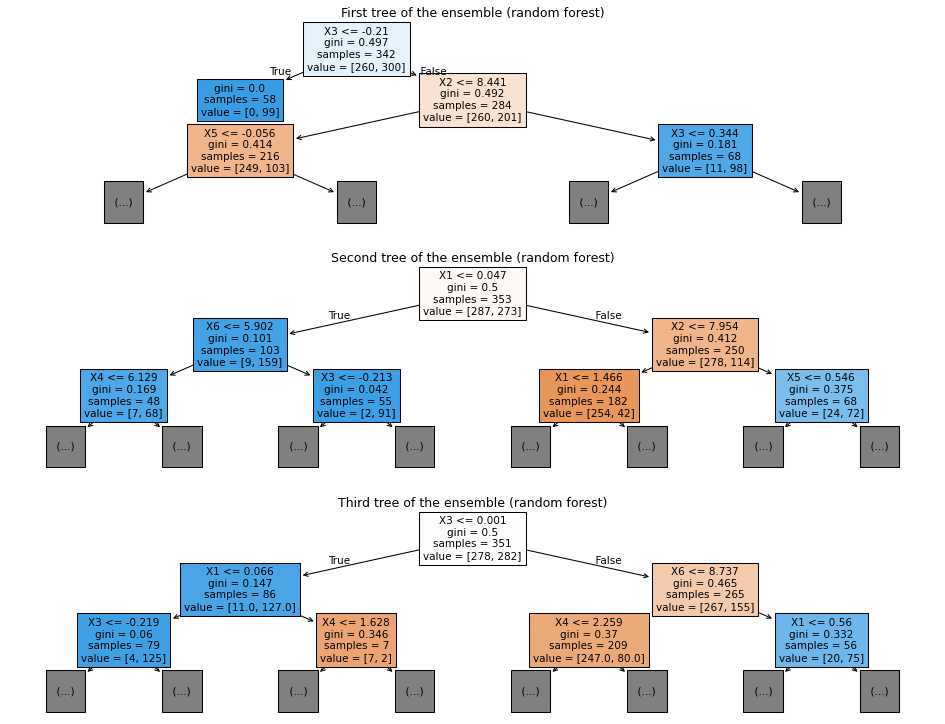

In [11]:
## Plot first trees of the ensemble
plt.figure(figsize=(16, 12))
plt.subplot(3,1,1)
plot_tree(RF_class_estim.estimators_[0], feature_names= INPUTS_RT, fontsize=10, filled=True, max_depth=2)
plt.title(f'First tree of the ensemble (random forest)')
plt.subplot(3,1,2)
plot_tree(RF_class_estim.estimators_[1], feature_names= INPUTS_RT, fontsize=10, filled=True, max_depth=2)
plt.title(f'Second tree of the ensemble (random forest)')
plt.subplot(3,1,3)
plot_tree(RF_class_estim.estimators_[2], feature_names= INPUTS_RT, fontsize=10, filled=True, max_depth=2)
plt.title(f'Third tree of the ensemble (random forest)')
plt.show()

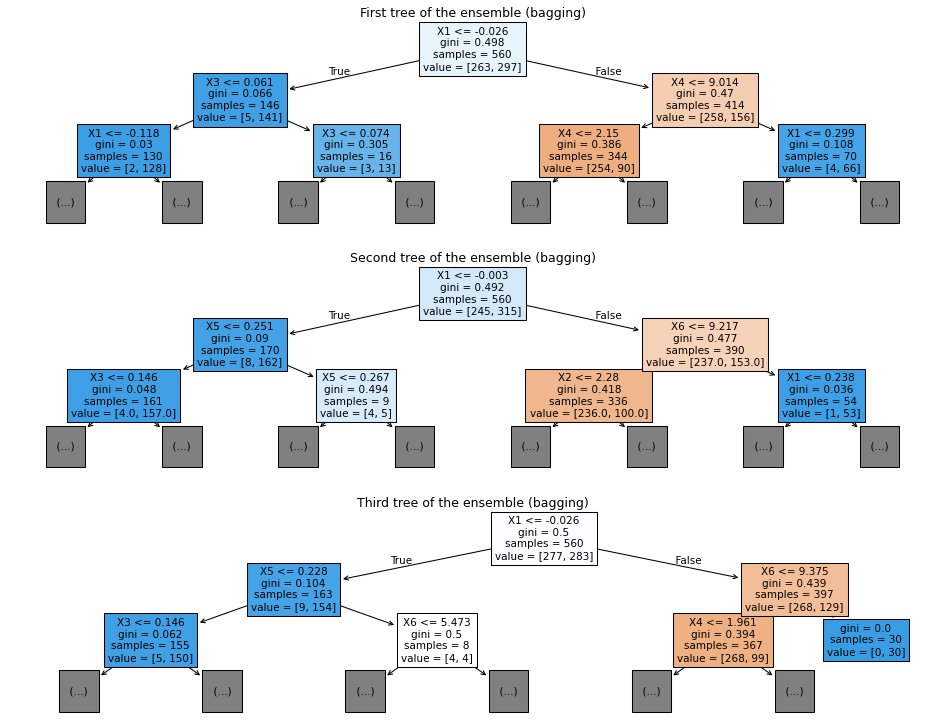

In [12]:
## Plot first trees of the ensemble of BAGGED TREES
plt.figure(figsize=(16, 12))
plt.subplot(3,1,1)
plot_tree(bag_class_estim.estimators_[0]['DT'], feature_names= INPUTS_BT, fontsize=10, filled=True, max_depth=2)
plt.title(f'First tree of the ensemble (bagging)')
plt.subplot(3,1,2)
plot_tree(bag_class_estim.estimators_[1]['DT'], feature_names= INPUTS_BT, fontsize=10, filled=True, max_depth=2)
plt.title(f'Second tree of the ensemble (bagging)')
plt.subplot(3,1,3)
plot_tree(bag_class_estim.estimators_[2]['DT'], feature_names= INPUTS_BT, fontsize=10, filled=True, max_depth=2)
plt.title(f'Third tree of the ensemble (bagging)')
plt.show()

#### 1.5.2 Importances of the inputs in the random forest

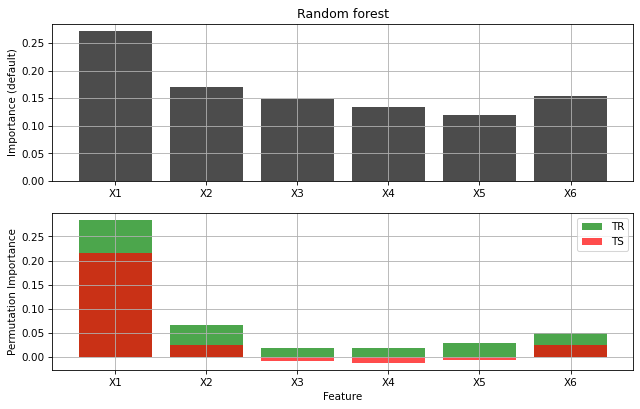

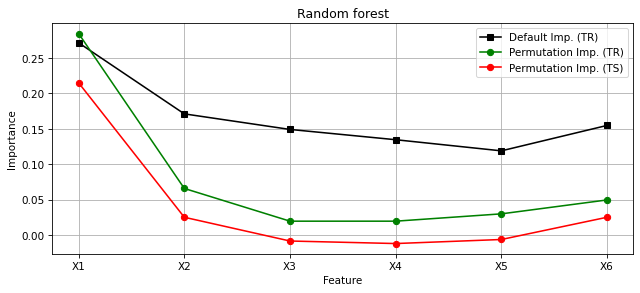

In [13]:
## Para medir la importancia, se usa primero el metodo por defecto de random forest y luego permutación.

## Feature importance evaluation using "Permutation Importance" (training and test)


importances_tr_RF_class_estim = permutation_importance(RF_class_estim, 
                                    X_train[INPUTS_RT], y_train,
                                    n_repeats=10,
                                    random_state=0)

importances_ts_RF_class_estim = permutation_importance(RF_class_estim, 
                                    X_test[INPUTS_RT], y_test,
                                    n_repeats=10,
                                    random_state=0)
 
## Plot importances

# Plot the variable importance of each feature given by feature_importances_ attribute
plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
plt.bar(INPUTS_RT, RF_class_estim.feature_importances_, color='black', alpha=0.7)
plt.ylabel('Importance (default)')
plt.title('Random forest')
plt.grid()

plt.subplot(2,1,2)
plt.bar(INPUTS_RT, importances_tr_RF_class_estim.importances_mean, color='green', alpha=0.7, label='TR')
plt.bar(INPUTS_RT, importances_ts_RF_class_estim.importances_mean, color='red', alpha=0.7, label='TS')
plt.xlabel('Feature')
plt.ylabel('Permutation Importance')
plt.legend()
plt.grid()
plt.show()

# Plot the variable importances of each feature (all together)
plt.figure(figsize=(10, 4))

plt.plot(INPUTS_RT, RF_class_estim.feature_importances_, 's-',  color='black', label='Default Imp. (TR)')
plt.plot(INPUTS_RT, importances_tr_RF_class_estim.importances_mean, 'o-', color='green', label='Permutation Imp. (TR)')
plt.plot(INPUTS_RT, importances_ts_RF_class_estim.importances_mean, 'o-', color='red', label='Permutation Imp. (TS)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random forest')
plt.legend()
plt.grid()
plt.show()

#### 1.5.3 Variability in the forest

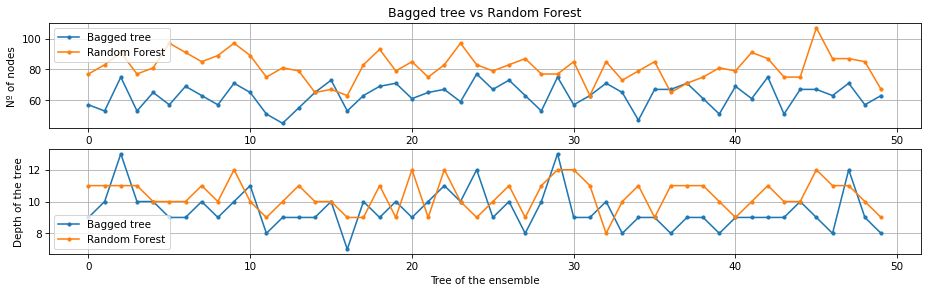

In [13]:
# number of nodes in each tree of the forest
node_count_trees_rf = [t.tree_.node_count for t in RF_class_estim.estimators_]

# number of nodes in each tree of the ensemble
depth_trees_rf = [t.tree_.max_depth for t in RF_class_estim.estimators_]

fig = plt.figure(1, figsize=(15, 4))
ax1=plt.subplot(2,1,1)
plt.plot(node_count_trees_bt, '.-', label ='Bagged tree')
plt.plot(node_count_trees_rf, '.-', label ='Random Forest')
plt.ylabel('Nº of nodes')     
plt.title('Bagged tree vs Random Forest') 
plt.legend()        
plt.grid()

plt.subplot(2,1,2, sharex = ax1)
plt.plot(depth_trees_bt, '.-', label ='Bagged tree')
plt.plot(depth_trees_rf, '.-', label ='Random Forest')
plt.ylabel('Depth of the tree')                       
plt.xlabel('Tree of the ensemble')                  
plt.grid()
plt.legend()        
plt.show()

## Random forest tiene mas nodos porque al no dejarle seleccionar todas las variables, va a tardar, de media, mas en encontrar la solucion.

## 1.6 Fit optimal Random Forest using Grid Search

In [14]:
# find optim nº of trees in the ensemble and max_features
param = {'RF__max_features': range(1, 6, 1), # Number number of features to consider when looking for the best split
         'RF__n_estimators': range(20, 150, 5)} # Number of trees in the forest

pipe =  Pipeline(steps=[('RF', 
                            RandomForestClassifier(
                                        criterion='gini',  # impurity measure
                                        min_samples_split=2, # Minimum number of obs in node to keep cutting
                                        min_samples_leaf=1, # Minimum number of obs in a terminal node  
                                        random_state=0)
                        )])

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
rf_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds,  # Number of Folds
                       refit=True) # (default) the best model is finally refitted using the whole training set **

# fit the bagged trees
INPUTS_RT = INPUTS  
rf_fit.fit(X_train[INPUTS_RT], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('RF',
                                        RandomForestClassifier(random_state=0))]),
             n_jobs=-1,
             param_grid={'RF__max_features': range(1, 6),
                         'RF__n_estimators': range(20, 150, 5)},
             scoring='accuracy')

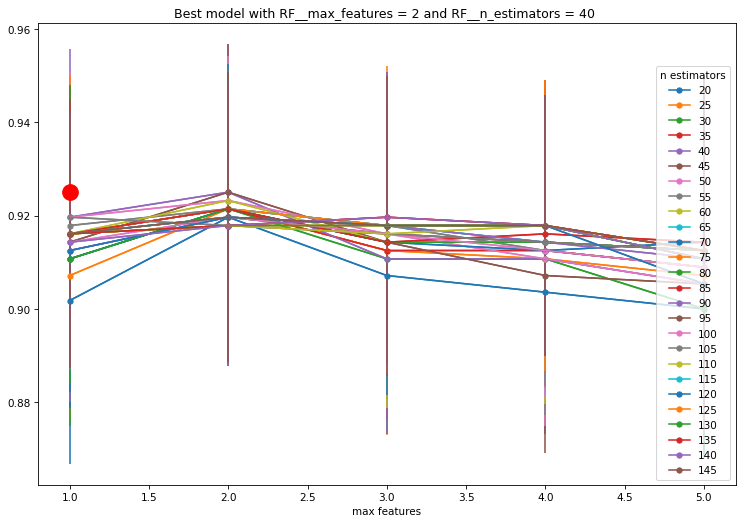

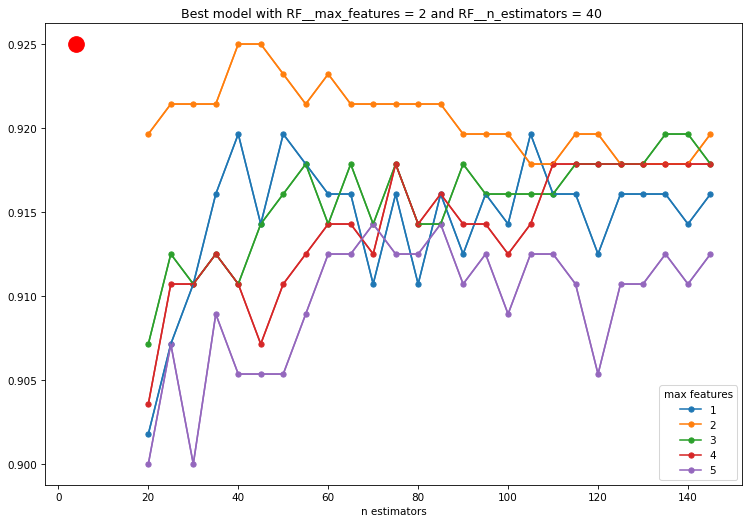

In [15]:
uml1.plotModelGridError(rf_fit)

#### 1.7.1 Compute errors of the forest

In [16]:
# model predictions in training (TR) and test (TS) sets
clf = rf_fit
y_train_pred = clf.predict(X_train[INPUTS_RT]).tolist()
y_test_pred = clf.predict(X_test[INPUTS_RT]).tolist()

# main metrics
acc_tr = metrics.accuracy_score(y_train,y_train_pred)
acc_ts = metrics.accuracy_score(y_test,y_test_pred)

acc_bal_tr = metrics.balanced_accuracy_score(y_train,y_train_pred)
acc_bal_ts = metrics.balanced_accuracy_score(y_test,y_test_pred)

dfacc =  pd.DataFrame([[acc_tr, acc_ts], [acc_bal_tr, acc_bal_ts]], index= ['Accuracy', 'Balanced accuracy'],  columns=['TR', 'TS'])
print(dfacc)

print('\nMETRICS TRAINING:')
uml1.confusion_matrix(y_train, y_train_pred, labels=['INS','OUT'])
print('\nMETRICS TEST SET:')
uml1.confusion_matrix(y_test, y_test_pred, labels=['INS','OUT'])

                         TR        TS
Accuracy           0.996429  0.914286
Balanced accuracy  0.996364  0.914268

METRICS TRAINING:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS  273    2
      OUT    0  285

Accuracy: 1.0
No Information Rate: 0.5
Kappa: 0.99
Mcnemar's Test P-Value: 0.5
Sensitivity: 1.0
Specificity: 0.99
Precision: 1.0
Recall: 0.99
Prevalence: 0.51
Detection Rate: 0.51
Detection prevalence: 0.51
Balanced accuracy: 1.0
F1 Score: 1.0
Positive label: INS

METRICS TEST SET:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS   63    6
      OUT    6   65

Accuracy: 0.91
No Information Rate: 0.5
Kappa: 0.83
Mcnemar's Test P-Value: 1.0
Sensitivity: 0.92
Specificity: 0.91
Precision: 0.91
Recall: 0.91
Prevalence: 0.51
Detection Rate: 0.46
Detection prevalence: 0.51
Balanced accuracy: 0.91
F1 Score: 0.91
Positive label: INS


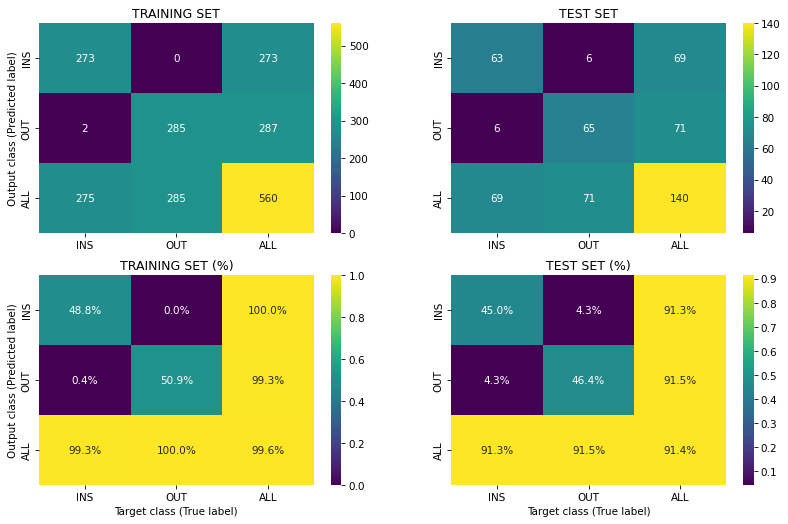

In [17]:
ucml2.plot_expanded_confusion_matrix(rf_fit, X_train, y_train, X_test, y_test)